In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
TRAIN_DIR = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train"
VAL_DIR = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val"
TEST_DIR = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test"

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Anthracnose', 'fruit_fly', 'healthy_guava']


In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
class GuavaEfficientNet(nn.Module):

    def __init__(self, num_classes):
        super(GuavaEfficientNet, self).__init__()

        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [10]:
num_classes = len(class_names)

model = GuavaEfficientNet(num_classes)
model = model.to(device)

print(model)

GuavaEfficientNet(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (sca

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [12]:
epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [13]:
for epoch in range(epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total


    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10
Train Loss: 26.9188 | Train Acc: 0.9158
Val Loss: 0.7918 | Val Acc: 0.9934
Epoch 2/10
Train Loss: 2.7709 | Train Acc: 0.9940
Val Loss: 0.2241 | Val Acc: 0.9974
Epoch 3/10
Train Loss: 1.0399 | Train Acc: 0.9992
Val Loss: 0.1350 | Val Acc: 0.9987
Epoch 4/10
Train Loss: 0.7071 | Train Acc: 0.9989
Val Loss: 0.0463 | Val Acc: 1.0000
Epoch 5/10
Train Loss: 0.8434 | Train Acc: 0.9981
Val Loss: 0.3289 | Val Acc: 0.9974
Epoch 6/10
Train Loss: 0.5492 | Train Acc: 0.9985
Val Loss: 0.0519 | Val Acc: 0.9987
Epoch 7/10
Train Loss: 0.7301 | Train Acc: 0.9974
Val Loss: 0.0597 | Val Acc: 0.9987
Epoch 8/10
Train Loss: 0.2122 | Train Acc: 0.9996
Val Loss: 0.0841 | Val Acc: 0.9987
Epoch 9/10
Train Loss: 0.5868 | Train Acc: 0.9985
Val Loss: 0.0585 | Val Acc: 0.9987
Epoch 10/10
Train Loss: 0.3013 | Train Acc: 0.9996
Val Loss: 0.2185 | Val Acc: 0.9987


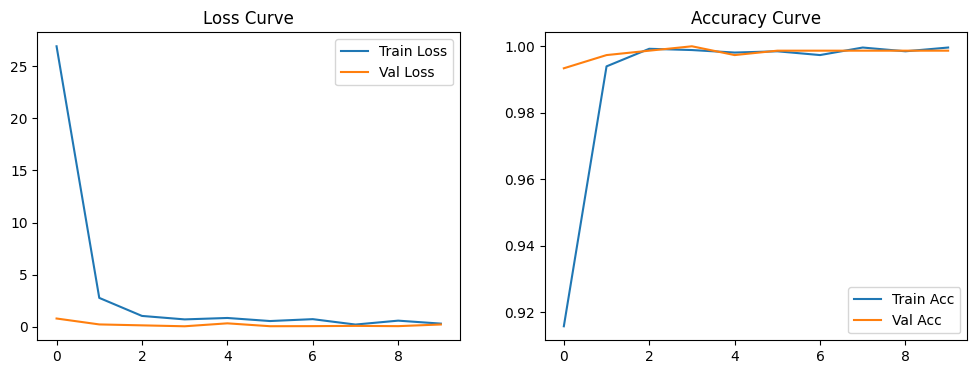

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history['train_loss'], label="Train Loss")
plt.plot(history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label="Train Acc")
plt.plot(history['val_acc'], label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [15]:
torch.save(model.state_dict(),"guava_efficientnet_model.pth")

In [16]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

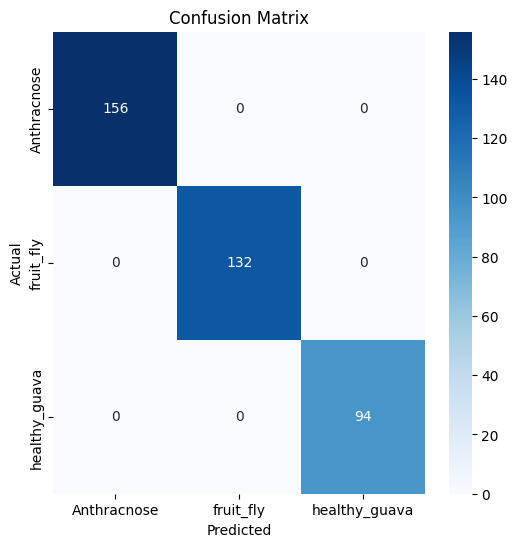

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
print(classification_report(all_labels, all_preds, target_names=class_names))

               precision    recall  f1-score   support

  Anthracnose       1.00      1.00      1.00       156
    fruit_fly       1.00      1.00      1.00       132
healthy_guava       1.00      1.00      1.00        94

     accuracy                           1.00       382
    macro avg       1.00      1.00      1.00       382
 weighted avg       1.00      1.00      1.00       382



In [19]:
num_classes = len(class_names)

labels_binarized = label_binarize(all_labels, classes=range(num_classes))

probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        prob = torch.softmax(outputs, dim=1)

        probs.extend(prob.cpu().numpy())

probs = np.array(probs)

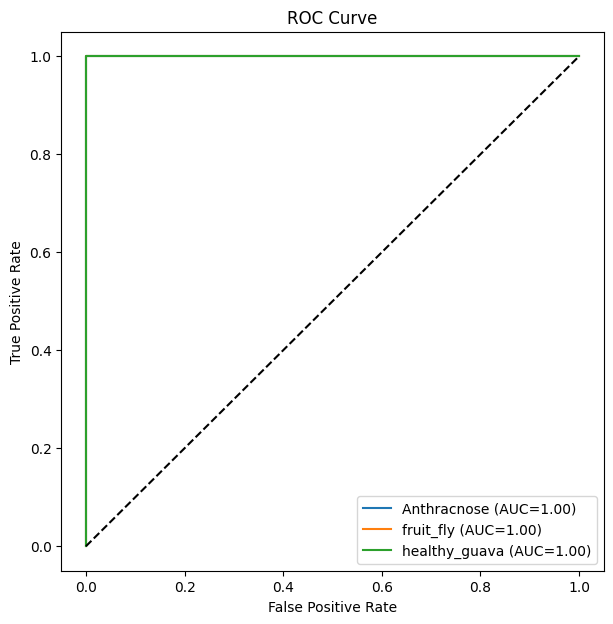

In [21]:
plt.figure(figsize=(7,7))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(labels_binarized[:,i], probs[:,i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()